# Data Loading and Cleaning: Telco Customer Churn Dataset

# 2. Introduction

This lab focuses on cleaning and preparing the Telco Customer Churn dataset for machine learning tasks. The dataset contains customer information such as demographics, services subscribed to, billing information, and whether the customer churned.

The main objective is to identify and handle missing values, remove duplicates, standardize categorical values, convert incorrect data types, and separate the target variable from the feature set.


# 3. Dataset Overview and Problem Type

### Dataset Name

Telco Customer Churn Dataset

### Problem Type

Classification

### Target Variable

Churn

The target variable contains two classes:

* Yes → Customer left the company
* No → Customer stayed with the company

### Real-World Importance

Telecommunication companies use churn prediction models to identify customers likely to leave their services. Early prediction helps companies take preventive actions and reduce revenue loss.


In [25]:
# 4. Import Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Explanation

* pandas → used for data loading and manipulation
* numpy → used for numerical operations
* matplotlib → used for plotting graphs and histograms


In [26]:
# 5. Load the Dataset
df = pd.read_csv('Telco_Customer_Churn.csv')
# Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Explanation

We load the dataset using `pd.read_csv()` and display the first five rows to verify that the dataset loaded correctly.


In [27]:
# 6. Inspect Dataset Shape
print('Dataset Shape:', df.shape)

Dataset Shape: (7043, 21)


### Explanation

The shape tells us:

* Number of rows (records)
* Number of columns (features)



In [28]:
# 7. Inspect Data Types and Missing Values
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Explanation

`df.info()` provides:

* Column names
* Data types
* Non-null values
* Missing values information

In [29]:
# 8. Display Column Names
print(df.columns)


Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')


### Explanation

This helps us understand all available features.


In [30]:
# 9. Summary Statistics
df.describe()


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


### Explanation

This shows:

* Mean
* Standard deviation
* Minimum and maximum values
* Quartiles

### Interpretation

You can inspect:

* MonthlyCharges distribution
* tenure distribution
* Potential outliers


In [31]:
# 10. Check Missing Values
missing_values = df.isnull().sum()
print(missing_values)


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


### Explanation

This calculates missing values in each column.

### Important Observation

Initially, most columns may show no missing values because blank spaces in `TotalCharges` are still treated as strings.


In [32]:
# 11. Convert TotalCharges to Numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Explanation

* `pd.to_numeric()` converts values into numeric format.
* `errors='coerce'` converts invalid values into NaN.

This step reveals hidden missing values.


In [33]:
# 12. Recheck Missing Values

missing_values = df.isnull().sum()
print(missing_values)


customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [34]:
# 13. Handle Missing Values

## Impute TotalCharges Using Median
median_value = df['TotalCharges'].median()

# Fill missing values
df['TotalCharges'].fillna(median_value, inplace=True)


C:\Users\HP\AppData\Local\Temp\ipykernel_3044\3601409427.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(median_value, inplace=True)


# Why Median?

Median is preferred because:

* It is robust to outliers
* Billing values may be skewed
* Extreme values do not heavily affect the median


In [35]:
# 14. Verify Missing Values Removed
print(df.isnull().sum())


customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [36]:
# 15. Check Duplicate Rows
duplicates = df.duplicated().sum()
print('Duplicate Rows:', duplicates)

Duplicate Rows: 0


### Explanation

Duplicate records can negatively affect model performance.


In [37]:
# 16. Remove Duplicates (If Present)
if duplicates > 0:
    df.drop_duplicates(inplace=True)
    print('Duplicates Removed')
else:
    print('No Duplicate Rows Found')


No Duplicate Rows Found


# Explanation

If duplicate rows exist, they are removed using `drop_duplicates()`.


In [38]:
# 17. Check Duplicate Customer IDs
customer_duplicates = df['customerID'].duplicated().sum()
print('Duplicate Customer IDs:', customer_duplicates)


Duplicate Customer IDs: 0


## Explanation

Each customer should have a unique customerID.


In [39]:
# 18. Standardize Categorical Columns

## Convert Text to Lowercase and Remove Extra Spaces
categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = df[col].str.strip().str.lower()


### Explanation

This step:

* Removes extra spaces
* Converts text into lowercase
* Ensures consistency before encoding


In [40]:
# 19. Verify Data Types Again
print(df.dtypes)

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


## Explanation

This confirms that:

* TotalCharges is now numeric
* Other columns remain correctly formatted


In [41]:
# 20. Explore Target Variable Distribution
print(df['Churn'].value_counts())


Churn
no     5174
yes    1869
Name: count, dtype: int64


### Explanation

This shows:

* Number of churned customers
* Number of non-churned customers

### Interpretation

The dataset is imbalanced because fewer customers churn.



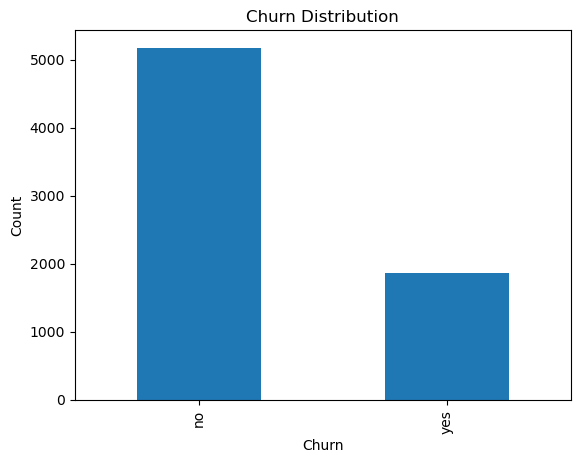

In [42]:
# 21. Plot Churn Distribution
df['Churn'].value_counts().plot(kind='bar')
plt.title('Churn Distribution')
plt.xlabel('Churn')
plt.ylabel('Count')
plt.show()


### Explanation

This graph visually shows class imbalance.


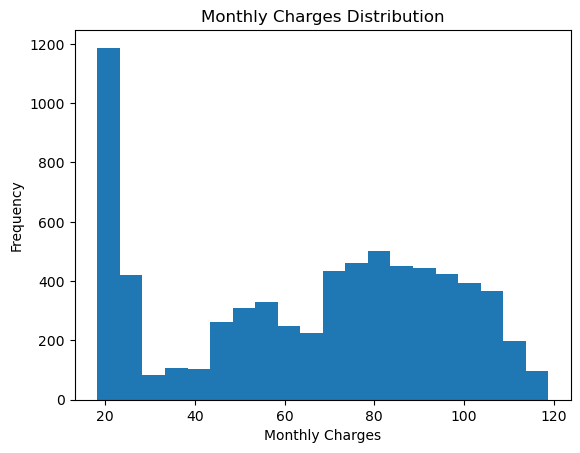

In [43]:
# 22. Explore Numerical Features

## Histogram of Monthly Charges

plt.hist(df['MonthlyCharges'], bins=20)
plt.title('Monthly Charges Distribution')
plt.xlabel('Monthly Charges')
plt.ylabel('Frequency')
plt.show()


# Interpretation

This helps identify:

* Distribution shape
* Outliers
* Skewness


In [44]:
# 23. Relationship Between Tenure and Churn
print(df.groupby('Churn')['tenure'].mean())


Churn
no     37.569965
yes    17.979133
Name: tenure, dtype: float64


# Interpretation

Customers with longer tenure generally churn less.



In [45]:
# 24. Separate Features and Target Variable

# Define target variable
y = df['Churn']

# Drop target and identifier column
X = df.drop(columns=['customerID', 'Churn'])


# Explanation

* `y` contains labels/target variable
* `X` contains input features
* `customerID` is removed because identifiers do not help prediction


In [46]:
# 25. Check Shapes of X and y

print('Features Shape:', X.shape)
print('Target Shape:', y.shape)


Features Shape: (7043, 19)
Target Shape: (7043,)


In [47]:
# 26. Display Cleaned Dataset Preview

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-vhveg,female,0,yes,no,1,no,no phone service,dsl,no,...,no,no,no,no,month-to-month,yes,electronic check,29.85,29.85,no
1,5575-gnvde,male,0,no,no,34,yes,no,dsl,yes,...,yes,no,no,no,one year,no,mailed check,56.95,1889.50,no
2,3668-qpybk,male,0,no,no,2,yes,no,dsl,yes,...,no,no,no,no,month-to-month,yes,mailed check,53.85,108.15,yes
3,7795-cfocw,male,0,no,no,45,no,no phone service,dsl,yes,...,yes,yes,no,no,one year,no,bank transfer (automatic),42.30,1840.75,no
4,9237-hqitu,female,0,no,no,2,yes,no,fiber optic,no,...,no,no,no,no,month-to-month,yes,electronic check,70.70,151.65,yes


# Explanation

This verifies that cleaning steps were applied successfully.


In [48]:
# 27. Save Cleaned Dataset

# Save cleaned dataset
df.to_csv('telco_customer_churn_cleaned.csv', index=False)
print('Cleaned dataset saved successfully!')


Cleaned dataset saved successfully!


# Explanation

The cleaned dataset is saved for future labs such as:

* Exploratory Data Analysis (EDA)
* Feature Engineering
* Machine Learning Model Training


# 28. Final Summary

## Summary of Cleaning Steps

In this lab, the Telco Customer Churn dataset was cleaned and prepared for machine learning.

### Cleaning Steps Performed

1. Loaded dataset into pandas DataFrame
2. Inspected shape, columns, and data types
3. Converted `TotalCharges` from object to numeric
4. Handled missing values using median imputation
5. Checked and removed duplicate rows
6. Verified duplicate customer IDs
7. Standardized categorical values using lowercase and whitespace removal
8. Explored churn distribution and numerical features
9. Separated features (`X`) and target (`y`)
10. Saved cleaned dataset


# Why Data Cleaning is Important

Data cleaning improves:

* Model accuracy
* Data consistency
* Reliability of predictions
* Quality of machine learning results

Poor-quality data can lead to:

* Incorrect predictions
* Biased models
* Reduced performance



## Conclusion

The cleaned dataset is now ready for:

* Exploratory Data Analysis (EDA)
* Feature encoding
* Machine learning algorithms
* Classification modeling